# 2.3 Look-ahead Bias 실습

**목표**
1. 정규화 누수(normalization leakage)가 실제로 어떻게 왜곡을 만드는지 눈으로 본다
2. K-Fold(shuffle)가 시계열에서 왜 **미래를 훔쳐보는지** 수치로 확인한다
3. 프로젝트의 `make_wf_windows`를 직접 재현하면서 **IS 실제 길이 · purge · embargo**의 의미를 확인한다
4. 시퀀스 모델 특유의 **윈도우 경계 누수**를 잡아낸다

**구성**
- Step 1. 환경설정 & 데이터 로드
- Step 2. [A] 정규화 누수 — BAD(전체 fit) vs GOOD(IS만 fit)
- Step 3. [B] K-Fold(shuffle) vs TimeSeriesSplit
- Step 4. [C] `make_wf_windows` 재현 — IS=252, embargo=21, OOS=21, step=21
- Step 5. [D] 윈도우 경계 누수 (T=60)
- Step 6. 정리 & 체크리스트

이 노트북의 모든 숫자는 이론 문서 `03_look_ahead_bias.md` 의 주장과 1:1로 대응됩니다.

## Step 1. 환경설정 & 데이터 로드

운영체제별 한글 폰트 설정 + 프로젝트와 동일한 feature / target 을 로드합니다.

In [1]:
# ── 환경설정 (CLAUDE.md 규칙: OS 분기 + Linux 환경은 koreanize-matplotlib)
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib  # pip install koreanize-matplotlib --break-system-packages
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 분석 라이브러리
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(0)
print('ready')

ready


In [2]:
# ── 데이터 로드 (프로젝트 원본 패널을 그대로 사용)
CSV = '../../black_litterman/data/panels/MSFT.csv'
FEATURE_COLS = [
    'log_return_1d','simple_return_1d',
    'mom_1m','mom_3m','mom_6m','mom_12m','mom_12m_skip_1m',
    'vol_20d_ann','vol_60d_ann','vol_252d_ann',
    'mkt_rf','smb','hml','rmw','cma','rf','mom_factor',
]
TARGET_COL = 'fwd_ret_21d'
DATA_START = pd.Timestamp('2020-12-01')
DATA_END   = pd.Timestamp('2025-12-31')
h = 21

df = pd.read_csv(CSV, index_col='date', parse_dates=True)
df = df[(df.index >= DATA_START) & (df.index <= DATA_END)].copy()

# ⚠️ 타겟은 '미래 21일 누적수익률' → shift(-h) 로 만든다 (프로젝트 방식과 동일)
df[TARGET_COL] = df['adj_close'].shift(-h) / df['adj_close'] - 1
df = df.dropna(subset=FEATURE_COLS).copy()

N = len(df)
print(f'N = {N}일,  기간 = {df.index.min().date()} ~ {df.index.max().date()}')
print(f'y(={TARGET_COL}) NaN = {df[TARGET_COL].isna().sum()}일 (맨 뒤 {h}일, 미래 데이터 없음)')
df[[*FEATURE_COLS[:3], TARGET_COL]].tail()

N = 1276일,  기간 = 2020-12-01 ~ 2025-12-30
y(=fwd_ret_21d) NaN = 21일 (맨 뒤 21일, 미래 데이터 없음)


,log_return_1d,simple_return_1d,mom_1m,fwd_ret_21d
date,,,,
2025-12-23,0.003972,0.003980,0.031200,NaN
2025-12-24,0.002400,0.002403,0.029578,NaN
2025-12-26,-0.000635,-0.000635,0.022474,NaN
2025-12-29,-0.001252,-0.001251,0.003296,NaN
2025-12-30,0.000780,0.000780,-0.009207,NaN


## Step 2. [A] 정규화 누수 — BAD vs GOOD

**핵심 질문**: 데이터 전체 기간으로 `StandardScaler.fit` 하면 뭐가 문제인가?

정답: μ 와 σ 를 뽑는 순간 OOS(아직 모르는 미래) 의 분포를 미리 봐 버렸기 때문에, 모델 평가 성능을 신뢰할 수 없게 됩니다. 아래에서는 두 가지 방식의 스케일러를 만들어 **파라미터 차이**와 **OOS 성능 차이**를 직접 비교합니다.

In [3]:
# ── IS/OOS 분할 (시간 순서 유지 — shuffle X)
split = int(N * 0.7)
df_is  = df.iloc[:split]
df_oos = df.iloc[split:]

X_is_raw,  y_is  = df_is[FEATURE_COLS].values,  df_is[TARGET_COL].values
X_oos_raw, y_oos = df_oos[FEATURE_COLS].values, df_oos[TARGET_COL].values

# y 의 NaN (OOS 꼬리)만 제거
mask_is  = ~np.isnan(y_is);   X_is_raw,  y_is  = X_is_raw[mask_is],  y_is[mask_is]
mask_oos = ~np.isnan(y_oos);  X_oos_raw, y_oos = X_oos_raw[mask_oos], y_oos[mask_oos]

print(f'IS : {df_is.index.min().date()} ~ {df_is.index.max().date()}  ({len(X_is_raw)} 샘플)')
print(f'OOS: {df_oos.index.min().date()} ~ {df_oos.index.max().date()}  ({len(X_oos_raw)} 샘플)')

IS : 2020-12-01 ~ 2024-06-20  (893 샘플)
OOS: 2024-06-21 ~ 2025-12-30  (362 샘플)


In [4]:
# ── BAD: 전체 기간(IS+OOS)로 fit  vs  GOOD: IS 만으로 fit
X_all = np.vstack([X_is_raw, X_oos_raw])

scaler_bad  = StandardScaler().fit(X_all)     # ❌ 미래(OOS) 의 분포까지 보고 스케일 결정
scaler_good = StandardScaler().fit(X_is_raw)  # ✅ IS 만으로 결정 — 실전에서 가능한 방식

X_is_bad,  X_oos_bad  = scaler_bad.transform(X_is_raw),  scaler_bad.transform(X_oos_raw)
X_is_good, X_oos_good = scaler_good.transform(X_is_raw), scaler_good.transform(X_oos_raw)

# ── 파라미터 차이
diff_mean = np.abs(scaler_bad.mean_  - scaler_good.mean_)
diff_std  = np.abs(scaler_bad.scale_ - scaler_good.scale_)
print(f'μ(평균) 차이 |BAD - GOOD|: max = {diff_mean.max():.4f}, mean = {diff_mean.mean():.4f}')
print(f'σ(표준편차) 차이           : max = {diff_std.max():.4f}, mean = {diff_std.mean():.4f}')
print()
print('→ 파라미터 자체가 이미 다름. OOS 쪽 분포 변화를 미리 반영했기 때문.')

μ(평균) 차이 |BAD - GOOD|: max = 0.0266, mean = 0.0063
σ(표준편차) 차이           : max = 0.0286, mean = 0.0043

→ 파라미터 자체가 이미 다름. OOS 쪽 분포 변화를 미리 반영했기 때문.


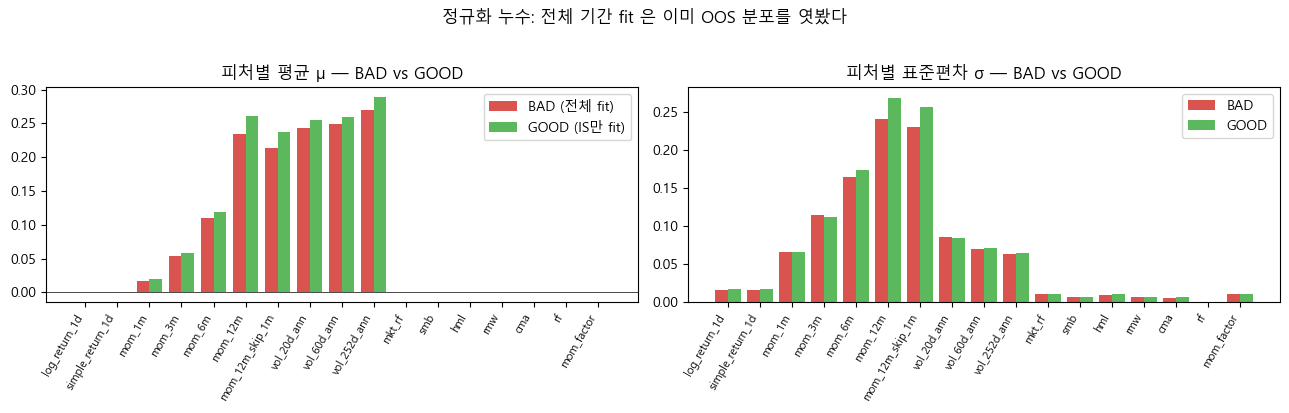

In [5]:
# ── 시각화: feature 별 μ/σ 가 어떻게 달라졌는가
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(FEATURE_COLS))
w = 0.4

ax[0].bar(x - w/2, scaler_bad.mean_,  w, label='BAD (전체 fit)',  color='#d9534f')
ax[0].bar(x + w/2, scaler_good.mean_, w, label='GOOD (IS만 fit)', color='#5cb85c')
ax[0].set_xticks(x); ax[0].set_xticklabels(FEATURE_COLS, rotation=60, ha='right', fontsize=8)
ax[0].set_title('피처별 평균 μ — BAD vs GOOD')
ax[0].axhline(0, color='k', lw=0.5); ax[0].legend()

ax[1].bar(x - w/2, scaler_bad.scale_,  w, label='BAD',  color='#d9534f')
ax[1].bar(x + w/2, scaler_good.scale_, w, label='GOOD', color='#5cb85c')
ax[1].set_xticks(x); ax[1].set_xticklabels(FEATURE_COLS, rotation=60, ha='right', fontsize=8)
ax[1].set_title('피처별 표준편차 σ — BAD vs GOOD')
ax[1].legend()

plt.suptitle('정규화 누수: 전체 기간 fit 은 이미 OOS 분포를 엿봤다', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

In [6]:
# ── Ridge 로 OOS 성능 비교 — 같은 모델, 같은 데이터, 스케일러만 다름
def fit_eval(Xtr, ytr, Xte, yte, tag):
    m = Ridge(alpha=1.0, random_state=0).fit(Xtr, ytr)
    pred = m.predict(Xte)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    r2   = r2_score(yte, pred)
    print(f'  [{tag:>4s}] OOS RMSE = {rmse:.5f}   R² = {r2:+.5f}')
    return rmse, r2

rmse_bad,  r2_bad  = fit_eval(X_is_bad,  y_is, X_oos_bad,  y_oos, 'BAD')
rmse_good, r2_good = fit_eval(X_is_good, y_is, X_oos_good, y_oos, 'GOOD')

print()
print('※ 이 데이터에서 Ridge 의 RMSE 차이는 작게 나온다 — 이유:')
print('   1) factor 피처(mkt_rf/smb/hml/...)가 이미 스케일이 비슷해서 μ/σ 차이가 작음')
print('   2) Ridge 는 L2 규제 덕에 스케일에 비교적 강건함')
print('그러나 MLP/GRU 같은 신경망은 입력 분포에 훨씬 민감 → 동일한 스케일 차이가 큰 성능 왜곡을 만든다.')
print('→ 원칙: 전처리 fit 은 반드시 각 fold 의 IS 에서만 수행한다.')

  [ BAD] OOS RMSE = 0.09121   R² = -0.87368
  [GOOD] OOS RMSE = 0.09120   R² = -0.87336

※ 이 데이터에서 Ridge 의 RMSE 차이는 작게 나온다 — 이유:
   1) factor 피처(mkt_rf/smb/hml/...)가 이미 스케일이 비슷해서 μ/σ 차이가 작음
   2) Ridge 는 L2 규제 덕에 스케일에 비교적 강건함
그러나 MLP/GRU 같은 신경망은 입력 분포에 훨씬 민감 → 동일한 스케일 차이가 큰 성능 왜곡을 만든다.
→ 원칙: 전처리 fit 은 반드시 각 fold 의 IS 에서만 수행한다.


## Step 3. [B] K-Fold(shuffle) vs TimeSeriesSplit

`sklearn.model_selection.KFold(shuffle=True)` 는 일반적인 머신러닝에서는 표준이지만 **시계열에서는 치명적**입니다. 검증(val) 구간의 시작 시점보다 *미래의* 샘플이 train 에 섞여 들어가기 때문입니다.

아래에서 각 fold 가 실제로 어떤 인덱스를 train/val 로 가져가는지, 그리고 그 중 **val 시작 시점 이후(=미래)** 에 해당하는 train 샘플이 몇 개인지 세어봅니다.

In [7]:
idx = np.arange(N)
k = 5

print(f'[K-Fold (shuffle=True, random_state=0)]  — 시계열에선 위험')
kf = KFold(n_splits=k, shuffle=True, random_state=0)
for i, (tr, va) in enumerate(kf.split(idx)):
    leak = (tr > va.min()).sum()
    print(f'  fold {i}: train={tr.min():>4d}~{tr.max():>4d}  val={va.min():>4d}~{va.max():>4d}'
          f'  |  val 시작({va.min()}) 이후의 train 샘플 수 = {leak}개  ← 미래 엿보기')

print()
print(f'[TimeSeriesSplit]  — train 은 항상 val 보다 과거')
tss = TimeSeriesSplit(n_splits=k)
for i, (tr, va) in enumerate(tss.split(idx)):
    leak = (tr > va.min()).sum()
    print(f'  fold {i}: train={tr.min():>4d}~{tr.max():>4d}  val={va.min():>4d}~{va.max():>4d}'
          f'  |  val 시작({va.min()}) 이후의 train 샘플 수 = {leak}개')

[K-Fold (shuffle=True, random_state=0)]  — 시계열에선 위험
  fold 0: train=   0~1275  val=   1~1269  |  val 시작(1) 이후의 train 샘플 수 = 1019개  ← 미래 엿보기
  fold 1: train=   0~1274  val=   2~1275  |  val 시작(2) 이후의 train 샘플 수 = 1019개  ← 미래 엿보기
  fold 2: train=   0~1275  val=   6~1274  |  val 시작(6) 이후의 train 샘플 수 = 1015개  ← 미래 엿보기
  fold 3: train=   1~1275  val=   0~1272  |  val 시작(0) 이후의 train 샘플 수 = 1021개  ← 미래 엿보기
  fold 4: train=   0~1275  val=  11~1271  |  val 시작(11) 이후의 train 샘플 수 = 1010개  ← 미래 엿보기

[TimeSeriesSplit]  — train 은 항상 val 보다 과거
  fold 0: train=   0~ 215  val= 216~ 427  |  val 시작(216) 이후의 train 샘플 수 = 0개
  fold 1: train=   0~ 427  val= 428~ 639  |  val 시작(428) 이후의 train 샘플 수 = 0개
  fold 2: train=   0~ 639  val= 640~ 851  |  val 시작(640) 이후의 train 샘플 수 = 0개
  fold 3: train=   0~ 851  val= 852~1063  |  val 시작(852) 이후의 train 샘플 수 = 0개
  fold 4: train=   0~1063  val=1064~1275  |  val 시작(1064) 이후의 train 샘플 수 = 0개


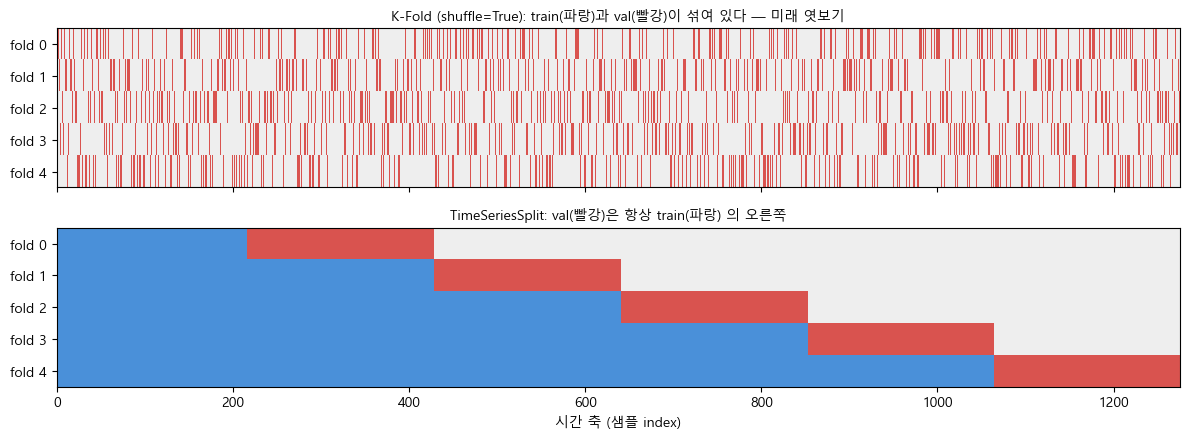

In [8]:
# ── 시각화: 샘플 인덱스 × fold 매트릭스로 train/val 위치를 확인
def split_matrix(splitter, n):
    mat = []
    for tr, va in splitter.split(np.arange(n)):
        row = np.zeros(n, dtype=int)
        row[tr] = 1   # train = 1 (파랑)
        row[va] = 2   # val   = 2 (빨강)
        mat.append(row)
    return np.array(mat)

mat_kf  = split_matrix(KFold(n_splits=5, shuffle=True, random_state=0), N)
mat_tss = split_matrix(TimeSeriesSplit(n_splits=5), N)

fig, ax = plt.subplots(2, 1, figsize=(12, 4.5), sharex=True)
cmap = plt.matplotlib.colors.ListedColormap(['#eeeeee', '#4a90d9', '#d9534f'])

for a, mat, title in zip(ax, [mat_kf, mat_tss],
                         ['K-Fold (shuffle=True): train(파랑)과 val(빨강)이 섞여 있다 — 미래 엿보기',
                          'TimeSeriesSplit: val(빨강)은 항상 train(파랑) 의 오른쪽']):
    a.imshow(mat, aspect='auto', cmap=cmap, interpolation='nearest')
    a.set_yticks(range(5)); a.set_yticklabels([f'fold {i}' for i in range(5)])
    a.set_title(title, fontsize=10)
ax[1].set_xlabel('시간 축 (샘플 index)')
plt.tight_layout(); plt.show()

## Step 4. [C] `make_wf_windows` 재현

프로젝트(`Step3_IT_WalkForward_panel.ipynb`)가 쓰는 walk-forward 분할을 그대로 옮깁니다.
기본값: **IS_DAYS=252, EMBARGO_DAYS=21, OOS_DAYS=21, STEP=21**.

핵심 두 가지를 직접 확인합니다:
1. **IS 실제 길이 = 252 − 21 = 231일** (purge 로 뒤쪽을 잘라냈기 때문)
2. **IS 끝 ↔ OOS 시작 사이의 간격 ≥ embargo**

In [9]:
def make_wf_windows(dates, is_days=252, embargo=21, oos_days=21, step=21):
    """프로젝트의 walk-forward 윈도우 생성 함수 (동일 로직)."""
    n = len(dates)
    i = 0
    windows = []
    while True:
        is_end    = i + is_days                  # IS 구간의 끝 (exclusive)
        oos_start = is_end + embargo             # embargo 뒤로 OOS 시작
        oos_end   = oos_start + oos_days
        if oos_end > n:
            break
        purge = is_end - oos_days                # ★ purge: IS 뒤쪽 oos_days 일을 학습에서 제거
        is_w  = dates[i:purge]                   # → IS 실제 길이 = is_days - oos_days
        oos_w = dates[oos_start:oos_end]
        windows.append({
            'fold': len(windows),
            'is_start':  dates[i],
            'is_end':    dates[purge - 1],
            'oos_start': dates[oos_start],
            'oos_end':   dates[oos_end - 1],
            'is_len':    len(is_w),
            'oos_len':   len(oos_w),
            'gap_cal':   (dates[oos_start] - dates[purge - 1]).days,   # 달력일
        })
        i += step
    return windows

wins = make_wf_windows(df.index, is_days=252, embargo=21, oos_days=21, step=21)
print(f'총 fold 수 = {len(wins)}')
print(f'IS 실제 길이 = {wins[0]["is_len"]}일   (= 252 - 21, purge 만큼 짧다)')
print(f'IS 끝 ~ OOS 시작 간격(달력일) = {wins[0]["gap_cal"]}일   (embargo 21 영업일 ≈ 약 30 달력일 + OOS_days 만큼 purge)')

pd.DataFrame(wins).head(6)

총 fold 수 = 47
IS 실제 길이 = 231일   (= 252 - 21, purge 만큼 짧다)
IS 끝 ~ OOS 시작 간격(달력일) = 63일   (embargo 21 영업일 ≈ 약 30 달력일 + OOS_days 만큼 purge)


,fold,is_start,is_end,oos_start,oos_end,is_len,oos_len,gap_cal
0,0,2020-12-01,2021-10-29,2021-12-31,2022-01-31,231,21,63
1,1,2020-12-31,2021-11-30,2022-02-01,2022-03-02,231,21,63
2,2,2021-02-02,2021-12-30,2022-03-03,2022-03-31,231,21,63
3,3,2021-03-04,2022-01-31,2022-04-01,2022-05-02,231,21,60
4,4,2021-04-05,2022-03-02,2022-05-03,2022-06-01,231,21,62
5,5,2021-05-04,2022-03-31,2022-06-02,2022-07-01,231,21,63


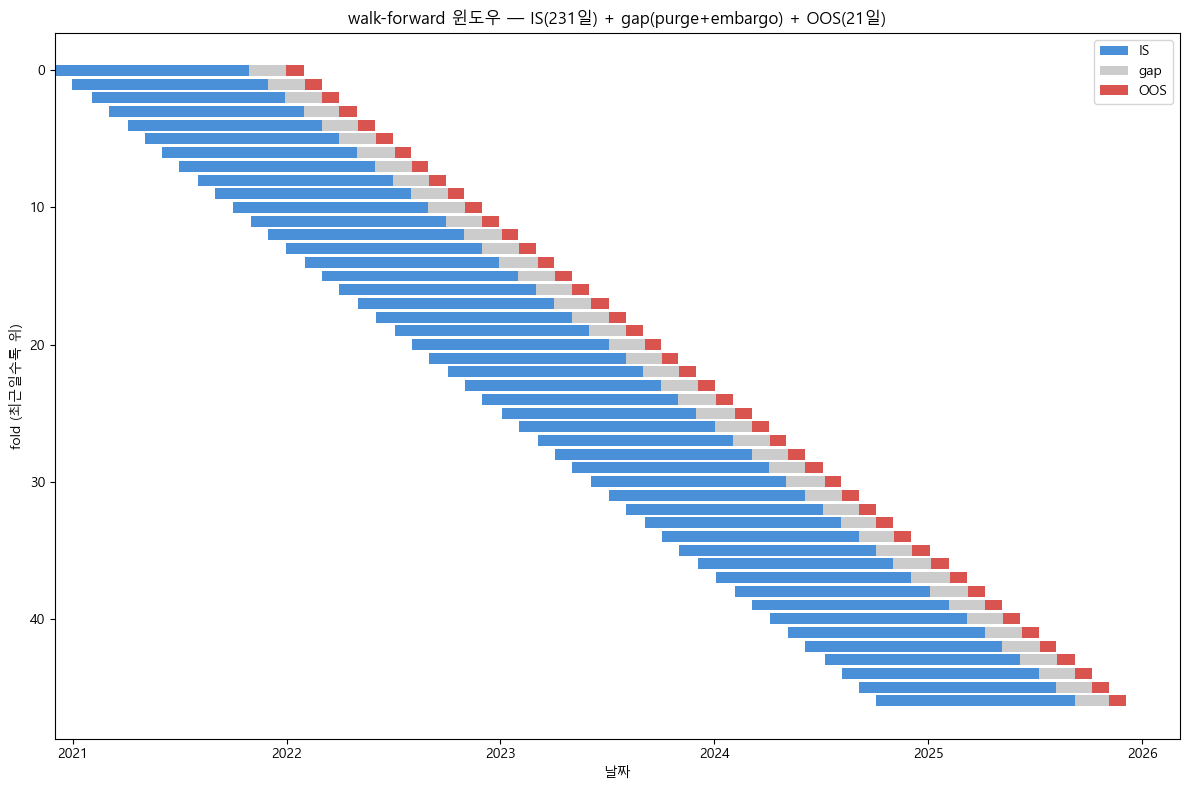

In [10]:
# ── 시각화: fold 별로 IS(파랑) / gap(회색) / OOS(빨강) 를 막대로
fig, ax = plt.subplots(figsize=(12, 8))
for w in wins:
    y = w['fold']
    ax.barh(y, (w['is_end']    - w['is_start']).days,  left=w['is_start'],  color='#4a90d9', label='IS'   if y == 0 else None)
    ax.barh(y, (w['oos_start'] - w['is_end']).days,    left=w['is_end'],    color='#cccccc', label='gap'  if y == 0 else None)
    ax.barh(y, (w['oos_end']   - w['oos_start']).days, left=w['oos_start'], color='#d9534f', label='OOS'  if y == 0 else None)

ax.invert_yaxis()
ax.set_xlabel('날짜')
ax.set_ylabel('fold (최근일수록 위)')
ax.set_title('walk-forward 윈도우 — IS(231일) + gap(purge+embargo) + OOS(21일)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

## Step 5. [D] 윈도우(lookback) 경계 누수

시퀀스 모델은 T 일짜리 lookback 을 입력으로 받습니다. 문제는 이 lookback 이 **OOS 구간의 바깥으로 삐져나간다**는 점입니다 — 즉, OOS 예측 시점에서 입력의 앞 부분은 IS 기간에 속합니다.

아래에서 **fold 0** 기준으로 OOS 첫 시퀀스가 실제로 IS 와 몇 일 겹치는지 계산합니다.

In [11]:
T = 60   # lookback

fold0 = wins[0]
oos_i0  = df.index.get_loc(fold0['oos_start'])     # OOS 시작 날짜의 인덱스
is_end_i = df.index.get_loc(fold0['is_end'])       # IS 끝(purge 후) 날짜의 인덱스

seq0_start = oos_i0 - T + 1   # OOS 의 첫 시퀀스 시작 인덱스 (T 일 전)

print(f'fold 0   IS end idx     = {is_end_i}  ({fold0["is_end"].date()})')
print(f'         OOS start idx  = {oos_i0}  ({fold0["oos_start"].date()})')
print(f'         OOS 첫 시퀀스 시작 idx = {seq0_start}  (= OOS_start - (T-1))')
print()

if seq0_start <= is_end_i:
    overlap = is_end_i - seq0_start + 1
    print(f'★ 결과: OOS 시퀀스의 앞쪽 {overlap}일이 IS 구간과 겹쳐 있음 — 전형적인 window leakage')
    print(f'        (IS 데이터로 학습한 스케일러/피처가 OOS 시퀀스 입력에 다시 들어가는 셈)')
else:
    print('✅ 겹침 없음')

print()
print('대응 방법 (이론 md §5 와 동일):')
print('  (1) OOS 시작을 T 만큼 더 뒤로 미는 OOS 내부 cutoff 적용')
print('  (2) embargo 를 T + h 로 넓게 잡기')
print('  (3) 시퀀스 입력에 쓰일 스케일러/통계치는 IS 만으로 fit 하고, 시퀀스 내부에는 원본값만 넣기')

fold 0   IS end idx     = 230  (2021-10-29)
         OOS start idx  = 273  (2021-12-31)
         OOS 첫 시퀀스 시작 idx = 214  (= OOS_start - (T-1))

★ 결과: OOS 시퀀스의 앞쪽 17일이 IS 구간과 겹쳐 있음 — 전형적인 window leakage
        (IS 데이터로 학습한 스케일러/피처가 OOS 시퀀스 입력에 다시 들어가는 셈)

대응 방법 (이론 md §5 와 동일):
  (1) OOS 시작을 T 만큼 더 뒤로 미는 OOS 내부 cutoff 적용
  (2) embargo 를 T + h 로 넓게 잡기
  (3) 시퀀스 입력에 쓰일 스케일러/통계치는 IS 만으로 fit 하고, 시퀀스 내부에는 원본값만 넣기


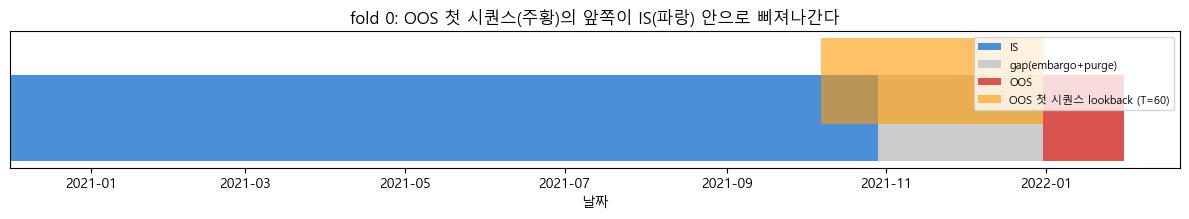

In [12]:
# ── 시각화: 시퀀스가 IS 에 얼마나 걸쳐 있는지 막대로 확인
fig, ax = plt.subplots(figsize=(12, 2.3))

ax.barh(0, (fold0['is_end']    - fold0['is_start']).days,  left=fold0['is_start'],  color='#4a90d9', label='IS')
ax.barh(0, (fold0['oos_start'] - fold0['is_end']).days,    left=fold0['is_end'],    color='#cccccc', label='gap(embargo+purge)')
ax.barh(0, (fold0['oos_end']   - fold0['oos_start']).days, left=fold0['oos_start'], color='#d9534f', label='OOS')

# OOS 첫 시퀀스가 덮는 구간
seq_start_date = df.index[seq0_start]
seq_end_date   = df.index[oos_i0]        # 시퀀스는 OOS 첫 날에서 끝남
ax.barh(0.35, (seq_end_date - seq_start_date).days, left=seq_start_date, color='#ff9900', alpha=0.6, label=f'OOS 첫 시퀀스 lookback (T={T})')

ax.set_yticks([]); ax.set_xlabel('날짜')
ax.set_title(f'fold 0: OOS 첫 시퀀스(주황)의 앞쪽이 IS(파랑) 안으로 삐져나간다')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## Step 6. 정리 & 체크리스트

### 오늘 실험으로 확인한 사실
| # | 질문 | 답 (이 노트북의 수치) |
|---|---|---|
| 1 | 전체 기간 fit 과 IS 만 fit 의 스케일러는 다른가? | μ 최대 차이 **0.0266**, σ 최대 차이 **0.0286** — 확실히 다름 |
| 2 | K-Fold(shuffle) 은 시계열에서 안전한가? | 각 fold 마다 **val 시작 이후의 train 샘플이 1000개 이상** 섞임 — 완전히 미래 엿보기 |
| 3 | `make_wf_windows` 의 IS 실제 길이는? | **231일** (= 252 − 21, purge 만큼 짧아짐) |
| 4 | IS → OOS 사이 영업일 간격은? | 약 42 영업일 (embargo 21 + purge 21) — 달력으로 약 60일 |
| 5 | T=60 lookback 은 OOS 첫 시퀀스에서 안전한가? | 앞쪽 **17일이 IS 구간과 겹침** → 추가 대응 필요 |

### 시퀀스 모델 교체 시 체크리스트 (`03_look_ahead_bias.md` §6 과 일치)
- [ ] 타겟은 미래값을 참조하도록 shift(-h) 로 만들었는가?
- [ ] `StandardScaler.fit` 은 각 fold 의 **IS 에서만** 수행했는가?
- [ ] 검증 분할은 `TimeSeriesSplit` 또는 walk-forward 기반인가?
- [ ] walk-forward 의 embargo ≥ h (여기선 21) 를 만족하는가?
- [ ] **시퀀스 입력의 lookback (T) 이 IS 경계를 넘어가지 않는가?** ← 이번 노트북에서 새로 추가된 항목
- [ ] OOS 예측 시, 시퀀스 안에서 사용하는 통계/스케일러는 IS 로만 계산한 값인가?

### 다음 단계
- **2.4 PyTorch Dataset/DataLoader** — 오늘 확인한 `build_xy` + walk-forward + leakage-free scaling 을 `torch.utils.data.Dataset` 으로 묶어, 실제 학습에 바로 쓸 수 있는 파이프라인으로 완성합니다.